# **54.1: [CO4] Perform Customer Segmentation on Simulated Data**

Setup & Import Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Load Simulated Data

In [ ]:
from google.colab import files
uploaded = files.upload()

users = pd.read_csv('mock_users.csv')
sessions = pd.read_csv('mock_sessions.csv')
events = pd.read_csv('mock_events.csv')

print(users.shape, sessions.shape, events.shape)
users.head()

Saving mock_events.csv to mock_events (1).csv
Saving mock_sessions.csv to mock_sessions (1).csv
Saving mock_users.csv to mock_users (1).csv
(200, 7) (500, 6) (1000, 7)


,user_id,email,signup_timestamp,role,plan_type,acquisition_channel,country
0,U0001,user1@example.com,2023-04-13,Recruiter,paid,Website,India
1,U0002,user2@example.com,2023-06-29,HR,free,Referral,Germany
2,U0003,user3@example.com,2023-04-03,Analyst,free,Referral,US
3,U0004,user4@example.com,2023-01-15,Recruiter,trial,Website,India
4,U0005,user5@example.com,2023-04-17,Analyst,paid,Website,India


Feature Engineering (User Behavior Metrics)

In [ ]:
# Number of sessions per user
sessions_per_user = sessions.groupby('user_id')['session_id'].nunique().reset_index()
sessions_per_user.columns = ['user_id', 'num_sessions']

# Number of events per user
events_per_user = events.groupby('user_id')['event_id'].count().reset_index()
events_per_user.columns = ['user_id', 'num_events']

# Unique features used per user
features_used = events.groupby('user_id')['feature_area'].nunique().reset_index()
features_used.columns = ['user_id', 'unique_features_used']

# Combine all behavior features
user_features = users.merge(sessions_per_user, on='user_id', how='left') \
                     .merge(events_per_user, on='user_id', how='left') \
                     .merge(features_used, on='user_id', how='left')

# Fill missing values (for users without events/sessions)
user_features.fillna(0, inplace=True)

user_features.head()

,user_id,email,signup_timestamp,role,plan_type,acquisition_channel,country,num_sessions,num_events,unique_features_used
0,U0001,user1@example.com,2023-04-13,Recruiter,paid,Website,India,6.0,4.0,3.0
1,U0002,user2@example.com,2023-06-29,HR,free,Referral,Germany,1.0,2.0,2.0
2,U0003,user3@example.com,2023-04-03,Analyst,free,Referral,US,1.0,5.0,4.0
3,U0004,user4@example.com,2023-01-15,Recruiter,trial,Website,India,3.0,7.0,4.0
4,U0005,user5@example.com,2023-04-17,Analyst,paid,Website,India,5.0,4.0,3.0


Scale Features for Clustering

In [ ]:
scaler = StandardScaler()

X = user_features[['num_sessions', 'num_events', 'unique_features_used']]

X_scaled = scaler.fit_transform(X)

Determine Optimal Number of Clusters (Elbow Method)

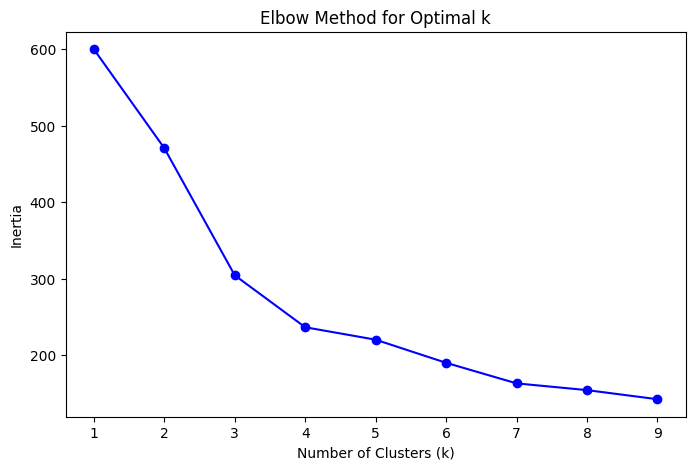

In [ ]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Apply KMeans Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
user_features['cluster'] = kmeans.fit_predict(X_scaled)

user_features.head()

,user_id,email,signup_timestamp,role,plan_type,acquisition_channel,country,num_sessions,num_events,unique_features_used,cluster
0,U0001,user1@example.com,2023-04-13,Recruiter,paid,Website,India,6.0,4.0,3.0,2
1,U0002,user2@example.com,2023-06-29,HR,free,Referral,Germany,1.0,2.0,2.0,1
2,U0003,user3@example.com,2023-04-03,Analyst,free,Referral,US,1.0,5.0,4.0,0
3,U0004,user4@example.com,2023-01-15,Recruiter,trial,Website,India,3.0,7.0,4.0,0
4,U0005,user5@example.com,2023-04-17,Analyst,paid,Website,India,5.0,4.0,3.0,2


Visualize the Segments

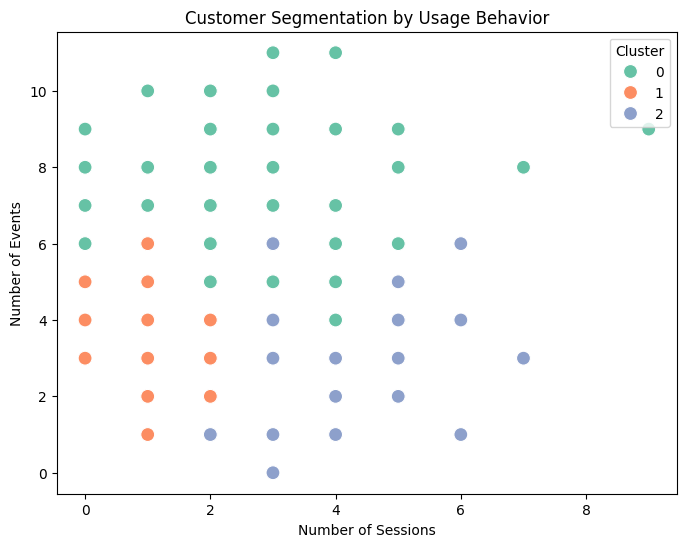

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='num_sessions',
    y='num_events',
    hue='cluster',
    data=user_features,
    palette='Set2',
    s=100
)
plt.title('Customer Segmentation by Usage Behavior')
plt.xlabel('Number of Sessions')
plt.ylabel('Number of Events')
plt.legend(title='Cluster')
plt.show()

Analyze Each Segment (Create Personas)

In [ ]:
cluster_summary = user_features.groupby('cluster')[['num_sessions', 'num_events', 'unique_features_used']].mean().reset_index()
cluster_summary

,cluster,num_sessions,num_events,unique_features_used
0,0,2.712500,7.000000,3.60
1,1,1.285714,3.914286,2.50
2,2,3.860000,3.320000,2.18


In [ ]:
from google.colab import files
user_features.to_csv('user_segments.csv', index=False)
files.download('user_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **55.1: [CO4] Develop Predictive LTV Model using Scikit-learn**

### Installing and importing required libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

### **Uploading dataset**

In [4]:
users = pd.read_csv('/content/drive/MyDrive/Hiring Heat-map Datasets /mock_users.csv')
sessions = pd.read_csv('/content/drive/MyDrive/Hiring Heat-map Datasets /mock_sessions.csv')
events = pd.read_csv('/content/drive/MyDrive/Hiring Heat-map Datasets /mock_events.csv')

print(users.shape, sessions.shape, events.shape)

(200, 7) (500, 6) (1000, 7)


### Feature Engineering for LTV Prediction

In [5]:
sessions_per_user = sessions.groupby('user_id')['session_id'].nunique().reset_index()
sessions_per_user.columns = ['user_id', 'num_sessions']

events_per_user = events.groupby('user_id')['event_id'].count().reset_index()
events_per_user.columns = ['user_id', 'num_events']

features_used = events.groupby('user_id')['feature_area'].nunique().reset_index()
features_used.columns = ['user_id', 'unique_features_used']

ltv_data = users.merge(sessions_per_user, on='user_id', how='left') \
                .merge(events_per_user, on='user_id', how='left') \
                .merge(features_used, on='user_id', how='left')

ltv_data.fillna(0, inplace=True)

np.random.seed(42)
ltv_data['total_revenue_12_months'] = (
    100 * np.random.rand(len(ltv_data)) +
    5 * ltv_data['num_sessions'] +
    2 * ltv_data['num_events'] +
    10 * ltv_data['unique_features_used']
)
ltv_data.head()

,user_id,email,signup_timestamp,role,plan_type,acquisition_channel,country,num_sessions,num_events,unique_features_used,total_revenue_12_months
0,U0001,user1@example.com,2023-04-13,Recruiter,paid,Website,India,6.0,4.0,3.0,105.454012
1,U0002,user2@example.com,2023-06-29,HR,free,Referral,Germany,1.0,2.0,2.0,124.071431
2,U0003,user3@example.com,2023-04-03,Analyst,free,Referral,US,1.0,5.0,4.0,128.199394
3,U0004,user4@example.com,2023-01-15,Recruiter,trial,Website,India,3.0,7.0,4.0,128.865848
4,U0005,user5@example.com,2023-04-17,Analyst,paid,Website,India,5.0,4.0,3.0,78.601864


### Preparing data for modelling

In [6]:
X = ltv_data[['num_sessions', 'num_events', 'unique_features_used']]
y = ltv_data['total_revenue_12_months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


### **Training Model**

#### Random Forest Regressor

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Evaluate Model Performance

In [9]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R²): {r2:.2f}\n")
    return mae, r2

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

Linear Regression Performance:
Mean Absolute Error (MAE): 26.09
R-squared (R²): 0.03

Random Forest Regressor Performance:
Mean Absolute Error (MAE): 24.61
R-squared (R²): 0.00



(24.61197200325364, 0.0017454727748633658)

### Analyze Feature Importances

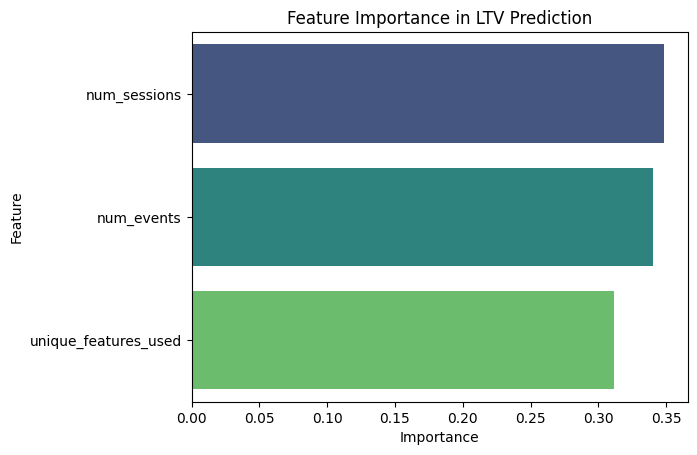

,Feature,Importance
0,num_sessions,0.348288
1,num_events,0.340447
2,unique_features_used,0.311265


In [11]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature',hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title("Feature Importance in LTV Prediction")
plt.show()

feature_importance_df